# EM-DAT: the Emergency Events Database

---
Literature:

Delforge, D., Wathelet, V., Below, R., Sofia, C. L., Tonnelier, M., von Loenhout, J. A. F. and Speybroeck, N. (2025). EM-DAT: the Emergency Events Database. *International Journal of Disaster Risk Reduction, 124*, 1-17. https://doi.org/10.1016/j.ijdrr.2025.105509

---
This notebook losely follows a tutorial from the EM-DAT GitHub (https://github.com/em-dat/python_tutorials/blob/main/python_tutorial_1_basic_operations_and_plotting.ipynb). It involves data laoding and data analysis using simple filtering, grouping and plotting methods.

## EM-DAT: Highlights

- Global disaster database tracking human and economic impacts from 1900 to present
- Two thirds of the 26'000+ unique disaster entries relate to natural hazards, predominently floods
- Open access: 
    - EM-DAT website: https://public.emdat.be
    - GitHub: https://github.com/em-dat 
- Limitations: known inconsistensies and biases in the data quality have been recorded, particularly for events before 2000

## 1. Loading and Inspecting the Data

The data from EM-DAT encompasses 26'000+ individual disasters, which are defined as events that overwhelm local capacity, meeting at least one of the following criteria:

- 10 deaths or above
- 100 people affected or above

In this notebook, we are only analysing floods, so all of the events in the dataset have: 
- Disaster Group: "Natural"
- Disaster Subgroup: "Hydrological"
- Disaster Type: "Flood"

Some of the variables we will use are summarized in the table below:
| Name                   | Type        | Description                                                                                                                |
|------------------------|-------------|----------------------------------------------------------------------------------------------------------------------------|
| Disaster Subtype       | string      | The disaster subtype. Options are 'Flood (General)', 'Flash flood', 'Riverine flood', 'Coastal flood'                      |
| Country                | string      | Country where the disaster occurred and had an impact using names from the UN M49 Standard.                                |
| ISO                    | string      | The international Organization for Standardization (ISO) 3-letter code referring to the country.                           |
| Region                 | string      | Region where the disaster occurred based on UN M49 standard. Options are: 'Americas', 'Africa', 'Asia', 'Europe', 'Oceania'|
| Start Year             | integer     | Year of occurrence of the disaster.                                                                                        |
| Magnitude              | float       | Value related to the intensity of a hazard depending on the disaster type.                                                 |
| Total Deaths           | float       | Total fatalities (deceased and missing combined).                                                                          |
| Total Affected         | float       | Total number of affected people (injured, homeless and/or affected)                                                        |

First, we load and inspect the data.

In [1]:
# Import modules
import pandas as pd 
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

# Check model versions
for i in [pd, mpl, np]:
    print(i.__name__, i.__version__)

pandas 2.3.3
matplotlib 3.9.4
numpy 2.0.2


As the data on events prior to 2000 have been particularly subject to reporting bias, the analysis exclusively considers floods that occurred since the year 2000. The data was downloaded from EM-DAT (https://public.emdat.be/) on March 24th, 2026, cleaned and saved under `floods.xlsx`.

In [3]:
# Load and inspect the data
floods = pd.read_excel("floods.xlsx")
floods.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4248 entries, 0 to 4247
Data columns (total 47 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   DisNo.                                     4248 non-null   object 
 1   Historic                                   4248 non-null   object 
 2   Classification Key                         4248 non-null   object 
 3   Disaster Group                             4248 non-null   object 
 4   Disaster Subgroup                          4248 non-null   object 
 5   Disaster Type                              4248 non-null   object 
 6   Disaster Subtype                           4248 non-null   object 
 7   External IDs                               1596 non-null   object 
 8   Event Name                                 11 non-null     object 
 9   ISO                                        4248 non-null   object 
 10  Country                 

We can a look at the first five rows of the data with `head()`.

In [4]:
floods.head()

,DisNo.,Historic,Classification Key,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,External IDs,Event Name,ISO,...,"Reconstruction Costs, Adjusted ('000 US$)",Insured Damage ('000 US$),"Insured Damage, Adjusted ('000 US$)",Total Damage ('000 US$),"Total Damage, Adjusted ('000 US$)",CPI,Admin Units,GADM Admin Units,Entry Date,Last Update
0,2018-0040-BRA,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),DFO:4576,NaN,BRA,...,NaN,NaN,NaN,10000.0,12492.0,80.049596,"[{""adm2_code"":9961,""adm2_name"":""Rio De Janeiro""}]","[{""gid_2"":""BRA.19.68_2"",""migration_date"":""2025...",2018-02-20,2025-12-20
1,2022-0770-RWA,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),NaN,NaN,RWA,...,NaN,NaN,NaN,NaN,NaN,93.294607,"[{""adm1_code"":21970,""adm1_name"":""Kigali City/U...","[{""gid_1"":""RWA.5_1"",""migration_date"":""2025-12-...",2022-11-25,2025-12-20
2,2000-0620-NGA,No,nat-hyd-flo-fla,Natural,Hydrological,Flood,Flash flood,NaN,NaN,NGA,...,NaN,NaN,NaN,4805.0,8753.0,54.895152,"[{""adm1_code"":2230,""adm1_name"":""Lagos""}]","[{""gid_1"":""NGA.25_1"",""migration_date"":""2025-12...",2005-09-15,2025-12-20
3,2022-0405-PAK,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),GLIDE:FL-2022-000270,NaN,PAK,...,10718733.0,7000.0,7503.0,15000000.0,16078100.0,93.294607,NaN,NaN,2022-07-07,2023-09-26
4,2022-0347-CIV,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),GLIDE:FL-2022-000249,NaN,CIV,...,NaN,NaN,NaN,NaN,NaN,93.294607,NaN,NaN,2022-06-29,2023-09-26


## 2. Example 1: Flooding in Indonesia

### 2.1 Filtering

This section focuses on all flooding events in Indonesia between 2010-2020. We can filter the data for floods in Indonesia between 2010-2020 and only keep the variables of interest, `Start Year`, `Total Deaths` and `Total Affected`. 

In [5]:
floods_idn = floods[
    (floods["ISO"] == "IDN") & 
    (floods["Start Year"] >= 2010) &
    (floods["Start Year"] <= 2020)
][['Start Year', 'Total Deaths', 'Total Affected']]

floods_idn.head()

,Start Year,Total Deaths,Total Affected
106,2019,2.0,2258.0
128,2018,3.0,12001.0
340,2019,2.0,2650.0
367,2010,291.0,12428.0
377,2011,18.0,3000.0


### 2.2 Grouping

In this section, we want to know the total number of people affected by flooding in Indonesia per year. With `groupby()`, we can group the data based on `Start Year`. To aggregate the total number of affected people per year, we can use `sum()`. Lastly, the results will be plotted using `plot()`.

<Axes: xlabel='Start Year', ylabel='People affected by floods'>

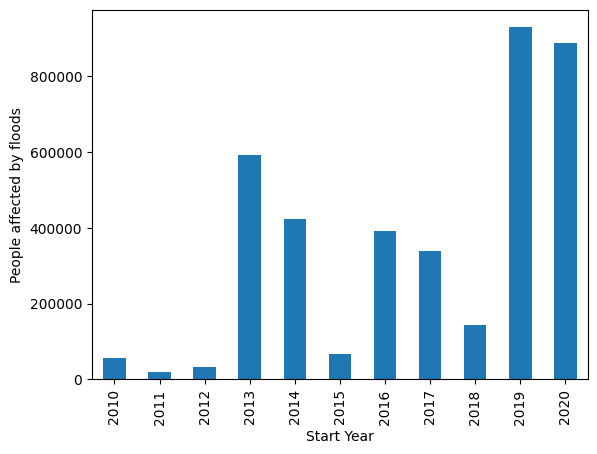

In [6]:
# Group the data by Start Year and aggregate the total number of affected people
grouped_idn = floods_idn.groupby("Start Year")["Total Affected"].sum()

# Create a bar plot
grouped_idn.plot(kind='bar', ylabel='People affected by floods')

### 2.3 Customize charts with `plt`

The submodel `plt` can be used to create customized charts.

<function matplotlib.pyplot.show(close=None, block=None)>

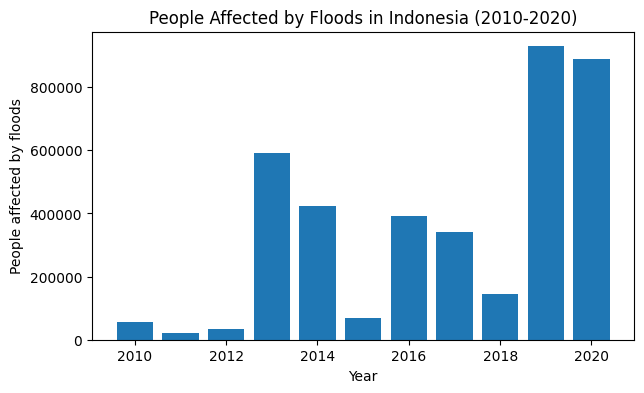

In [7]:
# Create a bar chart, similarly as in 2.2
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(grouped_idn.index, grouped_idn)

# Set axis labels and title
ax.set_xlabel('Year')
ax.set_ylabel('People affected by floods')
ax.set_title('People Affected by Floods in Indonesia (2010-2020)')

plt.show

## 3. Example 2: Comparing Regions

### 3.1 Flood-related deaths in different regions

In this section, the effects of floodings are compared across different regions. Again, we can filter the data for events between 2010-2020 and only keep the variables of interest, `Start Year`, `Region`, `Total Deaths` and `Total Affected`.

In [ ]:
# Filter the data
floods_all = floods[
    (floods["Start Year"] >= 2010) &
    (floods["Start Year"] <= 2020)
][['Start Year', 'Region', 'Total Deaths', 'Total Affected']]

floods_all.head()

,Start Year,Region,Total Deaths,Total Affected
0,2018,Americas,4.0,250.0
7,2010,Asia,NaN,30000.0
21,2019,Africa,19.0,1075.0
23,2019,Americas,1.0,2000.0
43,2018,Africa,NaN,200.0


The data is grouped by `Region`. Furthermore, we aggregate the variable `Total Deaths` using `sum`.

In [9]:
# Group the data by Region
floods_sum = floods_all.groupby(['Region'])['Total Deaths'].sum()
floods_sum

Region
Africa       8512.0
Americas     5465.0
Asia        41928.0
Europe        913.0
Oceania       141.0
Name: Total Deaths, dtype: float64

Next, we create a horizontal barchart visualising the total flood-induced deaths per region between 2010 and 2020 in descending order.

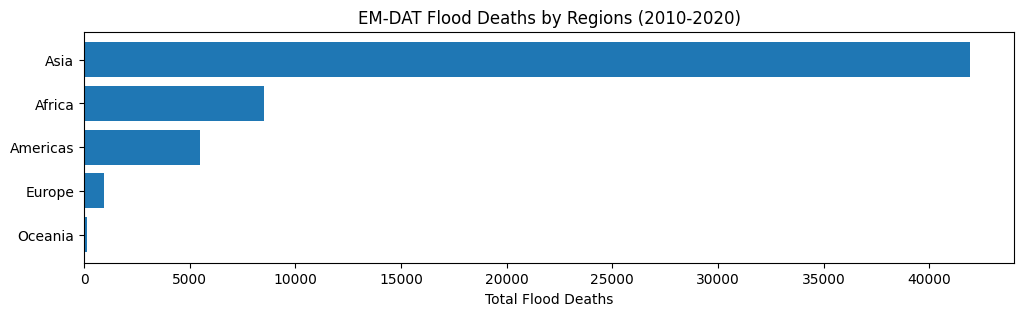

In [10]:
floods_sum_sorted = floods_sum.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 3))
ax.barh(floods_sum_sorted.index, floods_sum_sorted)
ax.set_xlabel('Total Flood Deaths')
ax.set_title('EM-DAT Flood Deaths by Regions (2010-2020)')

plt.show()

When interpreting this figure, we must be careful. For instance, the figure suggests that between 2010 and 2020, flood-related deaths in Asia were more than four times higher than in Africa. Why might this be misleading? What could potentially explain this difference?

Potential reasons could be:
- Total deaths not deaths per capita (Asia has a larger population than Africa)
- Threshold biases: EM-DAT only includes hazards associated with at least ten deaths or 100 affected. Naturally, some more moderate floodings are not reported.
- Systemic biases: EM-DAT sources data from various disaster reporting systems. Differences among these systems can induce biases. 
- Geographic biases: Geographic biases might occur from spatial inconsistencies in data coverage. Larger areas like Sub-Saharan Africa are often less well monitored. Furthermore, there might be discrepencies in the national reporting systems.
- Missing values

### 3.2 Missing values

One potential reason behind the differences between regions might be missing values. Therefore, we analyze the missing values in the variable `Total Deaths` and compare them across regions. Specifically, we calculate the number of missing values in `Total Deaths` per region and the percentage of floods reporting a missing value for `Total Deaths` per region.

In [11]:
# Get the number of missing values per region
na_summary = floods_all.groupby('Region')['Total Deaths'].agg(
    Total_Rows='size',
    NA_Count=lambda x: x.isna().sum()
)

# Calculate the NA percentage
na_summary['NA_Percentage'] = (
    na_summary['NA_Count'] / na_summary['Total_Rows'] * 100
)

na_summary = na_summary.reset_index()
na_summary

,Region,Total_Rows,NA_Count,NA_Percentage
0,Africa,415,108,26.024096
1,Americas,353,102,28.895184
2,Asia,731,109,14.911081
3,Europe,195,75,38.461538
4,Oceania,38,22,57.894737


`na_summary` shows that roughly 26% of the reported floods in Africa had a missing value for the variable `Total Deaths` compared to only 15% in Asia. For the other regions, the amount of missing values was even larger. This highlights that there are substantial reporting differences for different regions, which make comparisons between regions difficult.